In [1]:
import sys
from pathlib import Path
import itertools as it
import functools as ft

import polars as pl
import numpy as np
import plotnine as pn

import jax.numpy as jnp
from jax import grad, hessian, value_and_grad, vmap
from scipy.optimize import minimize

sys.path.append(str(Path.cwd().parent))
from display_hist import display_hist, display_vec

from sklearn.preprocessing import SplineTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

DATA_DIR = '../../data/citi_bike/'

# Gradient Boosting Parameters

In this post I'll walk through how you can use the same principles behind Gradient Boosting Machines (GBM) to predict _parameters_ of models in the same way traditional GBMs predict 1-dimensional targets. This allows us to get the benefits of Gradient Boosting (large feature sets, high dimensional interactions, modeling at scale) to fit things like smoothing splines, survival analaysis, and probabilistic models. Its not a [modeling silver bullet](https://multithreaded.stitchfix.com/blog/2015/07/30/gam/), but I think this approach can be a usefull tool to add to your modeling toolkit. Plus walking through this helped me understand gradient boosting at a deeper level than I did before, so hopefully you feel the same. 

### Gradient Boosting

Gradient Boosting is a Machine Learning algorithm that fits a series of decision trees; each successive tree attempts to improve the predictions from the set of previous trees. It (generally, there are many GBM implementations out there now) does this with two steps:
1. Before fitting a new tree calculate the gradient of the loss function we are minimizing at each observation
2. Fit a new decision tree that predicts^* this gradient and then add this prediction to the previous predictions. 

*(\*) technically fit the negative gradient, we want the loss to go down*

Recently I was reading about [Generalized Random Forests](https://arxiv.org/abs/1610.01271) (GRF) to learn how they used Random Forests to fit more complicated models than just regression and classification. This post started as a walkthrough of that technique, but I ended up trying something I've always had an idea for first; Can we use a GBM to fit distributions, not just make individual predictions? To test this I am goinging to walk through using Gradient Boosting to learn the coefficients for a spline function. We will use the Citi Bike Dataset to model the number of hourly rides over the course of a day.

[chart_that_shows_splines]

In [2]:
hourly_df = pl.read_parquet(DATA_DIR + 'hourly_rides_2022_2025.parquet')

In [3]:
hourly_df.head()

hour_start,ride_date,ride_hour,ride_count,weather_tmin_c,weather_tmax_c,weather_prcp_mm
datetime[μs],date,i64,u32,f64,f64,f64
2022-01-01 00:00:00,2022-01-01,0,1246,10.0,13.9,19.3
2022-01-01 01:00:00,2022-01-01,1,1379,10.0,13.9,19.3
2022-01-01 02:00:00,2022-01-01,2,1141,10.0,13.9,19.3
2022-01-01 03:00:00,2022-01-01,3,578,10.0,13.9,19.3
2022-01-01 04:00:00,2022-01-01,4,323,10.0,13.9,19.3


In [4]:
hourly_df = (
    hourly_df.
    with_columns(
        dow = pl.col('ride_date').dt.weekday(),
        woy = pl.col('ride_date').dt.week(),
        year = pl.col('ride_date').dt.year(),
        high_temp = pl.col('weather_tmin_c') * 1.8 + 32,
        low_temp = pl.col('weather_tmax_c') * 1.8 + 32,
        precip = pl.col('weather_prcp_mm') * 0.0393701
    )
)

In [5]:
FEATURE_COLS = ['dow', 'woy', 'year', 'high_temp', 'low_temp', 'precip']

daily_df = (
    hourly_df.
    group_by(*[FEATURE_COLS + ['ride_date']]).
    agg('ride_hour', 'ride_count').
    with_columns(
        pl.col('ride_hour').list.to_array(24),
        pl.col('ride_count').list.to_array(24)
    )
)

# remove no days
zero_days_df = (
    daily_df.
    select('ride_date', pl.col('ride_count').arr.sum()).
    filter(pl.col('ride_count') == 0)
)

daily_df = daily_df.join(zero_days_df, how='anti', on='ride_date')

### The Data

I've downloaded 4 years of the Citi Bike usage data and aggregated by the number of reachs in each hour of each day. Then I've also added the high and low temperature for that day as well as the inches of rain. If this were a proper forecasting model you'd want the _predicted_ weather for a day so your model was properly calibrated but this is fine for having features to learn parameters from. One unique thing about this data is that I have stored the hourly ride counts and the hour of the day in an aggregated polars array. This is so the splits will work on the daily level, since I need to generate spline coefficients for each day and apply them to the 24 hour range. If I was using a traditional GBM I would use the `ride_hour` as a feature and predict the hourly counts. 

In [6]:
daily_df.head()

dow,woy,year,high_temp,low_temp,precip,ride_date,ride_hour,ride_count
i8,i8,i32,f64,f64,f64,date,"array[i64, 24]","array[u32, 24]"
2,52,2022,29.12,35.06,0.0,2022-12-27,"[0, 1, … 23]","[285, 168, … 678]"
1,10,2022,50.0,73.94,0.051181,2022-03-07,"[0, 1, … 23]","[585, 356, … 798]"
3,44,2025,48.92,55.94,0.019685,2025-10-29,"[0, 1, … 23]","[1243, 602, … 2818]"
2,16,2023,46.94,57.02,0.0,2023-04-18,"[0, 1, … 23]","[688, 392, … 1290]"
6,42,2025,51.98,66.02,0.0,2025-10-18,"[0, 1, … 23]","[3551, 2447, … 4961]"


Lets use this data to fit a traditional GBM on the hourly data and visualize some results. 

In [7]:
#| echo: true
hourly_df = hourly_df.join(zero_days_df, how='anti', on='ride_date')

X_hourly = hourly_df[FEATURE_COLS + ['ride_hour']].to_numpy()
y_hourly = hourly_df['ride_count'].to_numpy()
y_hourly_log = np.log1p(y_hourly)

hourly_gbm = GradientBoostingRegressor(min_samples_leaf=4, validation_fraction=0.05)
hourly_gbm.fit(X_hourly, y_hourly_log)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [8]:

hourly_gbm_imp = {
    col: imp
    for col, imp in zip(FEATURE_COLS + ['ride_hour'], hourly_gbm.feature_importances_)}
# order dictionary by importance
hourly_gbm_imp = dict(sorted(hourly_gbm_imp.items(), key=lambda item: item[1], reverse=True))
print('GBM Regression Feature Importances:')
for col, imp in hourly_gbm_imp.items():
    print(f'{col}: {imp * 100:.2f}%')


GBM Regression Feature Importances:
ride_hour: 77.99%
low_temp: 6.20%
high_temp: 4.57%
dow: 3.46%
precip: 2.98%
year: 2.65%
woy: 2.15%


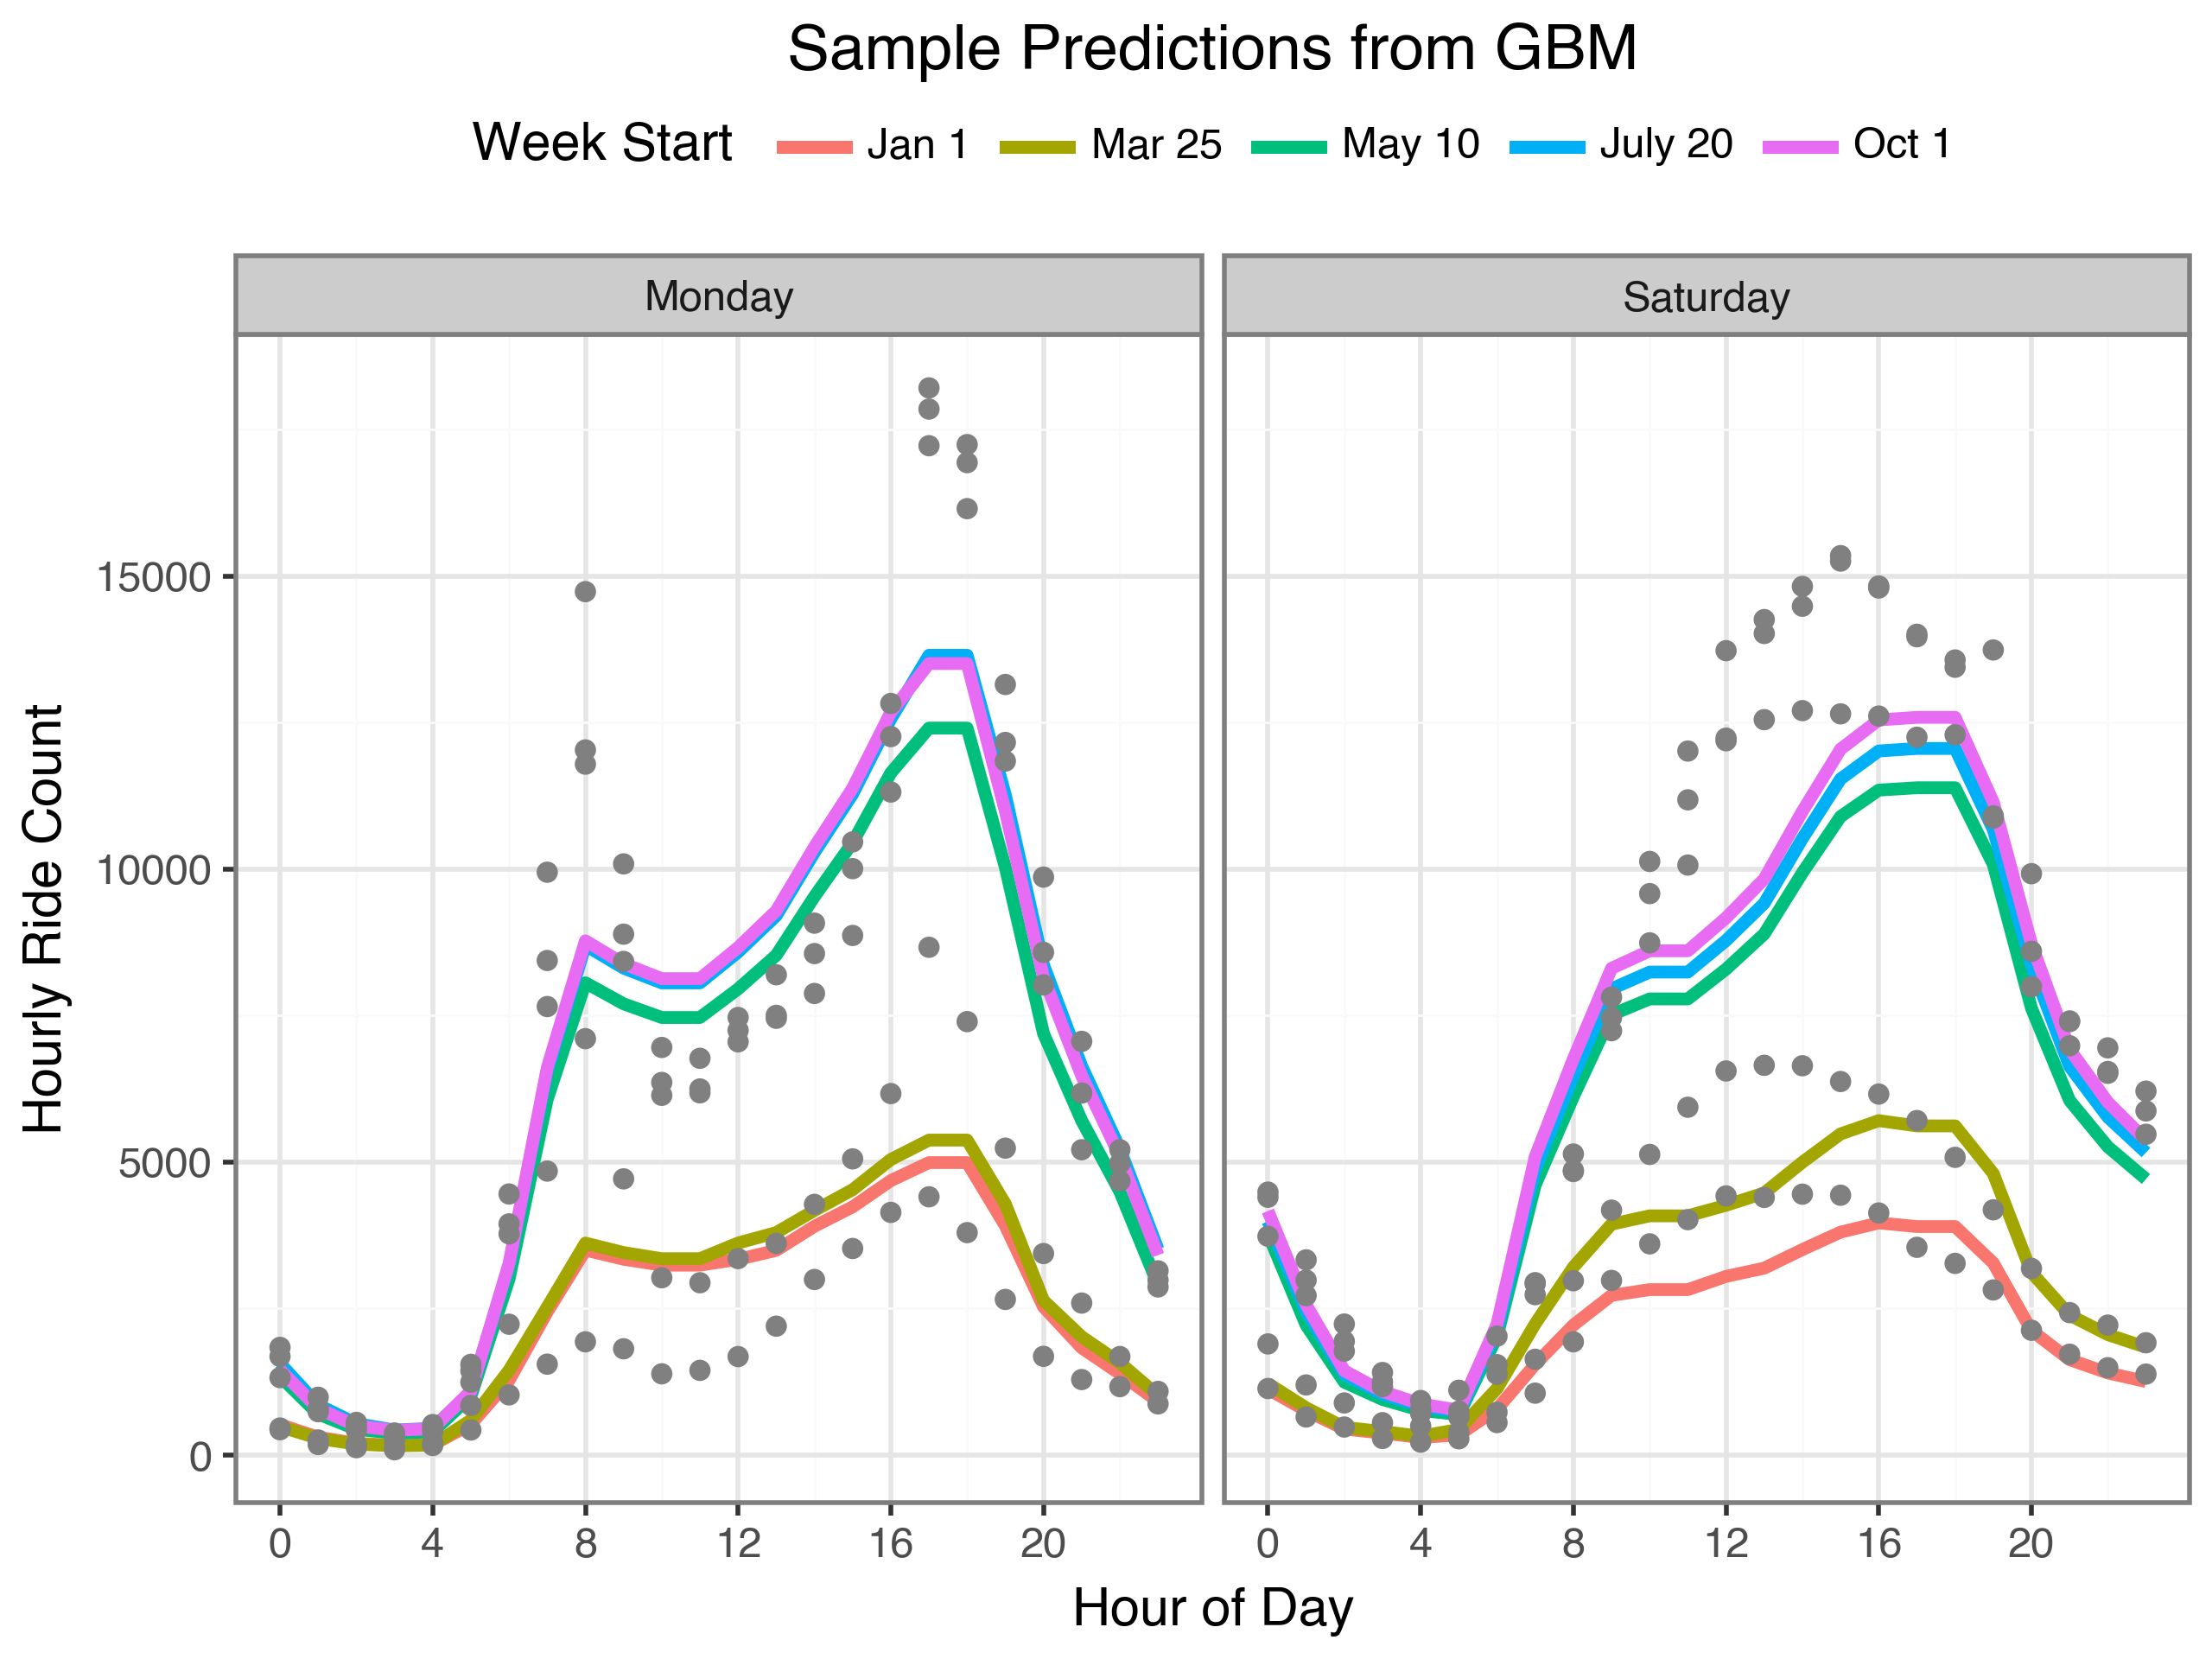

In [9]:
plot_data = (
    hourly_df.
    filter(pl.col('year') == 2025, pl.col('woy').is_in([1, 10, 20, 30, 40]), pl.col('dow').is_in([1, 6]))
)
#print(plot_data.sort('weather_prcp_mm', descending=True).select('ride_date', 'weather_prcp_mm').unique().head(3))
X_plot = plot_data[FEATURE_COLS + ['ride_hour']].to_numpy()
hourly_gbm_preds_plot = hourly_gbm.predict(X_plot)

woy_levels = ["Jan 1", "Mar 25", "May 10", "July 20", "Oct 1"]

plot_data = (
    plot_data.
    with_columns(pred = np.exp(hourly_gbm_preds_plot) - 1).
    with_columns(y_log = pl.col('ride_count').log1p()).
    with_columns(dow_ = pl.when(pl.col('dow') == 1).then(pl.lit('Monday')).when(pl.col('dow') == 6).then(pl.lit('Saturday')).otherwise(pl.lit('Other')),
                 woy_ = pl.when(pl.col('woy') == 1).then(pl.lit('Jan 1')).
                        when(pl.col('woy') == 10).then(pl.lit('Mar 25')).
                        when(pl.col('woy') == 20).then(pl.lit('May 10')).
                        when(pl.col('woy') == 30).then(pl.lit('July 20')).
                        when(pl.col('woy') == 40).then(pl.lit('Oct 1')).
                        otherwise(pl.lit('Other')).cast(pl.Enum(woy_levels)))
)

(
    pn.ggplot(plot_data.to_pandas(), pn.aes(x='ride_hour', y='pred', color='woy_', group = 'woy')) +
    pn.geom_line(size=1.5) +
    pn.geom_point(pn.aes(x='ride_hour', y='ride_count'), color='grey') +
    pn.scale_x_continuous(breaks=range(0, 24, 4), name = 'Hour of Day') +
    pn.scale_y_continuous(name = 'Hourly Ride Count') +
    pn.scale_color_discrete(name = 'Week Start') +
    pn.facet_wrap('dow_') +
    pn.ggtitle('Sample Predictions from GBM') +
    pn.theme_bw() +
    pn.theme(legend_position='top', dpi=200)#facet_text=pn.element_text(face='bold')) 
)

We can see this model has a hard time picking up on the different shapes between weekday and weekends. It also has some sharp corners that maybe we should try and smooth out. But what if we could use the same process of identiying optimal splits for a single hour's prediction in order to learn an entire coefficient vector? And yes, I'm just going to get ahead of any comments now; I'm not trying to make either model "the best" I'm only trying to work through the model fitting process. We are here for the journey, not the final validation loss value, ok?

### Gradient Boosting as Opimization

Traditionally Gradient Boosting Models are fit by learning the direction to move each prediction individually at each iteration. By using the gradient of that observation's prediction against the loss function as a "psuedo-label" we can learn a model to make predictions at that step. We can use the same procedure to fit a set of parameters and optimize them with the same algorithm. Then when we need to make a prediction we can use the predicted parameter values for that observation.

In our example we will calculate our parameter vectors $\theta$ for an observation $x$ at any iteration $m-1$ as the sum of all the individual predictions from our base learners $f_m(x)$

$$\hat{\theta}_{m-1} = \sum_{i \in m-1} f_{m-1}(x)$$

The base learners are models learned to predict the gradients of these parameters against our loss function

$$f_m(x) \sim \triangledown L(y, \hat{\theta}_{m-1})$$

In our example we need one extra step. If $b(\theta, x)$ is an individual model that generates predictions for a set of parameters $\theta$ and an observation $x$ then we calculate the gradients by how well the predictions from $b(\theta, x)$ predict our loss function $L$:

$$\triangledown L(y_i, b(\theta_{m-1}, x_i))$$

Then our decision tree will use $-g_{\theta}$ as the multitarget outputs and we can fit a decision tree to these targets. Since we have multiple parameter values in a smoothing spline we use a multitarget algorithm to make predictions for each dimension.

And our updates to our fitted parameters are 

$$\hat{\theta}_{m} = \hat{\theta}_{m-1} + \alpha * f_m(x)$$

Lets ease into this by mimicking what the tree splitting algorithm does to find optimal splits but with our paramters; coefficients for a smoothing spline of the hours of the day. 

### Optimal Spline Splits

Lets walk through this without worrying about trees and gradients. The goal here is to pick up on which feature value results in the most unique daily ride shape. We'll loop through values in a feature as the tree splitting algorithm will do. But for a first pass we will just measure how much variance there is from using the group average to predict the hourly ride counts. So for example we will measure the squared error from the observed counts with a single day of the week's average, and then do the same for all the other days as one group. The day with the lowest combined *Sum of Squared Errors* does the best job of splitting the data into coherent days of the week. 

In [10]:
def element_agg_df(df, group_col, agg_func=np.mean):
    """Aggregate an array column for each group"""
    array = df['ride_count'].to_numpy()
    #array = np.vstack(array)
    agg_values = agg_func(array, axis=0)
    return pl.DataFrame(
        {group_col: df[group_col].first(),
         'ride_count_avg': [agg_values]})

def calc_hourly_loss_sse(df, group_col):
    """Measure the error of using the group average as a prediction for each day"""
    group_avg = (
        df.group_by(group_col).
        map_groups(lambda df: element_agg_df(df, group_col))
    )

    pred_df = (
        df.
        join(group_avg, on = group_col, how='inner').
        with_columns(error = pl.col('ride_count') - pl.col('ride_count_avg')).
        group_by(group_col).
        # because the hourly counts are in arrays we have to square the 
        # errors individually first
        agg(sse = pl.col('error').arr.eval(pl.element().pow(2)).arr.sum().sum()).
        sort(group_col)
    )

    return pred_df

test = calc_hourly_loss_sse(daily_df, 'dow')

In [11]:
dows = range(1, 8)
dow_results = {
    i: calc_hourly_loss_sse(daily_df.with_columns(is_dow = pl.col('dow') == i), 'is_dow').sort('is_dow')
    for i in dows}
dow_result = pl.DataFrame(
    [
        {"Day of Week": i, "SSE": df["sse"].sum()}
        for i, df in dow_results.items()
    ]
)
dow_result

Day of Week,SSE
i64,f64
1,2.1539e11
2,2.1197e11
3,2.1273e11
4,2.1379e11
5,2.1624e11
6,2.0468e11
7,2.0292e11


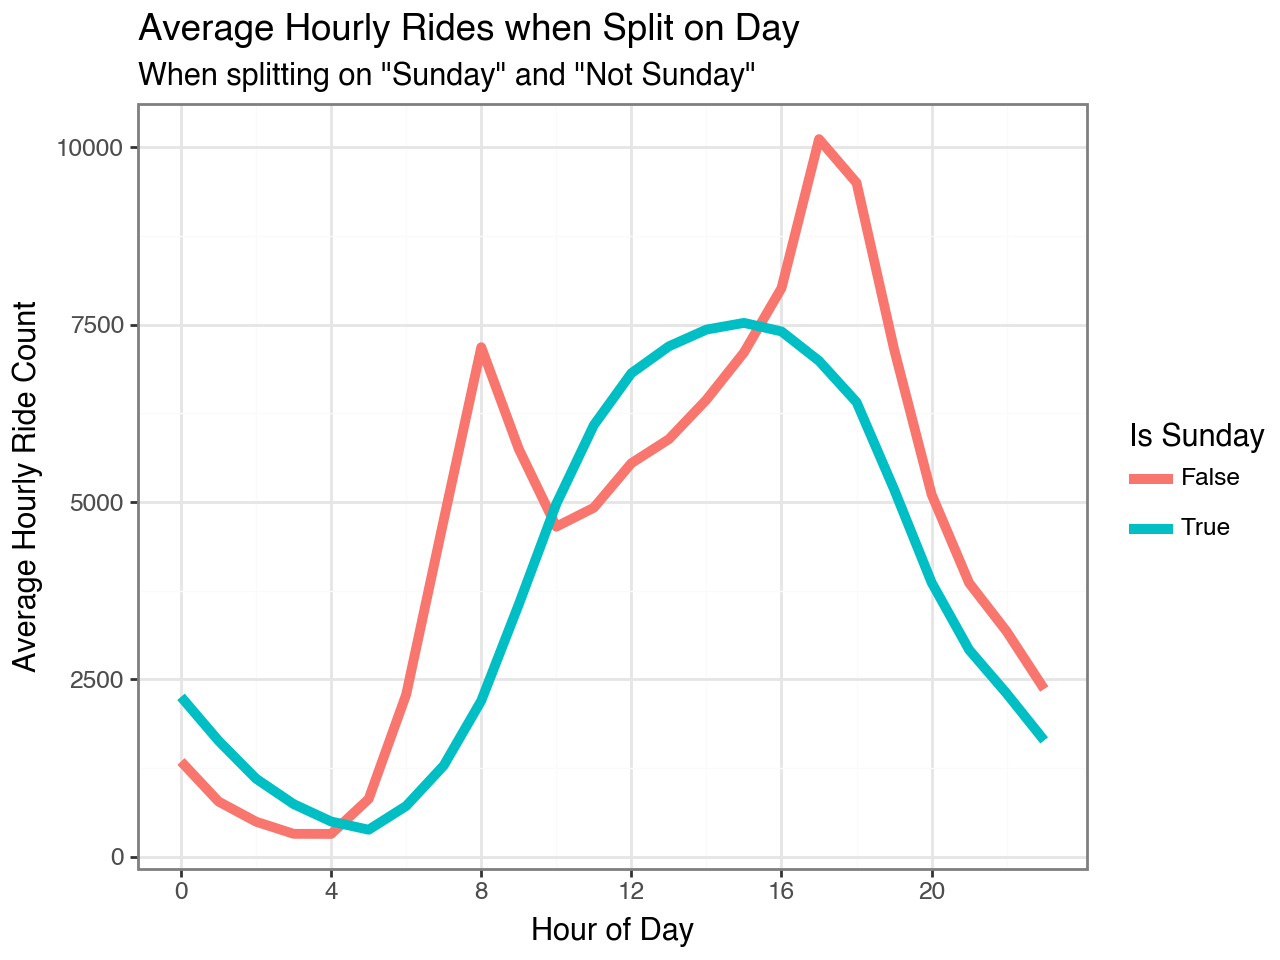

In [12]:
plot_df = (
    hourly_df.
    with_columns(is_7 = pl.col('dow') == 7).
    group_by('is_7', 'ride_hour').agg(pl.col('ride_count').mean())
)

pn.ggplot(plot_df, pn.aes(x='ride_hour', y='ride_count', color='is_7')) +\
    pn.geom_line(size=2) +\
    pn.ylab('Average Hourly Ride Count') +\
    pn.xlab('Hour of Day') +\
    pn.scale_color_discrete(name = 'Is Sunday') +\
    pn.scale_x_continuous(breaks=range(0, 24, 4)) +\
    pn.theme_bw() +\
    pn.ggtitle('Average Hourly Rides when Split on Day') +\
    pn.labs(subtitle='When splitting on "Sunday" and "Not Sunday"')

So Sunday has the most unique shape by this measure. The other days would have had more total error across all observations if we had split on one of them instead. We can do the same thing by the Weeks of the Year. 

In [13]:
woys = hourly_df['woy'].unique().sort()[:-1]
woy_results = {
    i: calc_hourly_loss_sse(daily_df.with_columns(is_le_woy = pl.col('woy') <= i), 'is_le_woy')
    for i in woys}
woy_result = [
    {'Week of Year': i, 'SSE': df['sse'].sum()} for i, df in woy_results.items()]
pl.DataFrame(woy_result).sort(pl.col('SSE'), descending=False).head(5)

Week of Year,SSE
i64,f64
14,1.7068e11
15,1.7146e11
13,1.7213e11
12,1.7354e11
16,1.7379e11


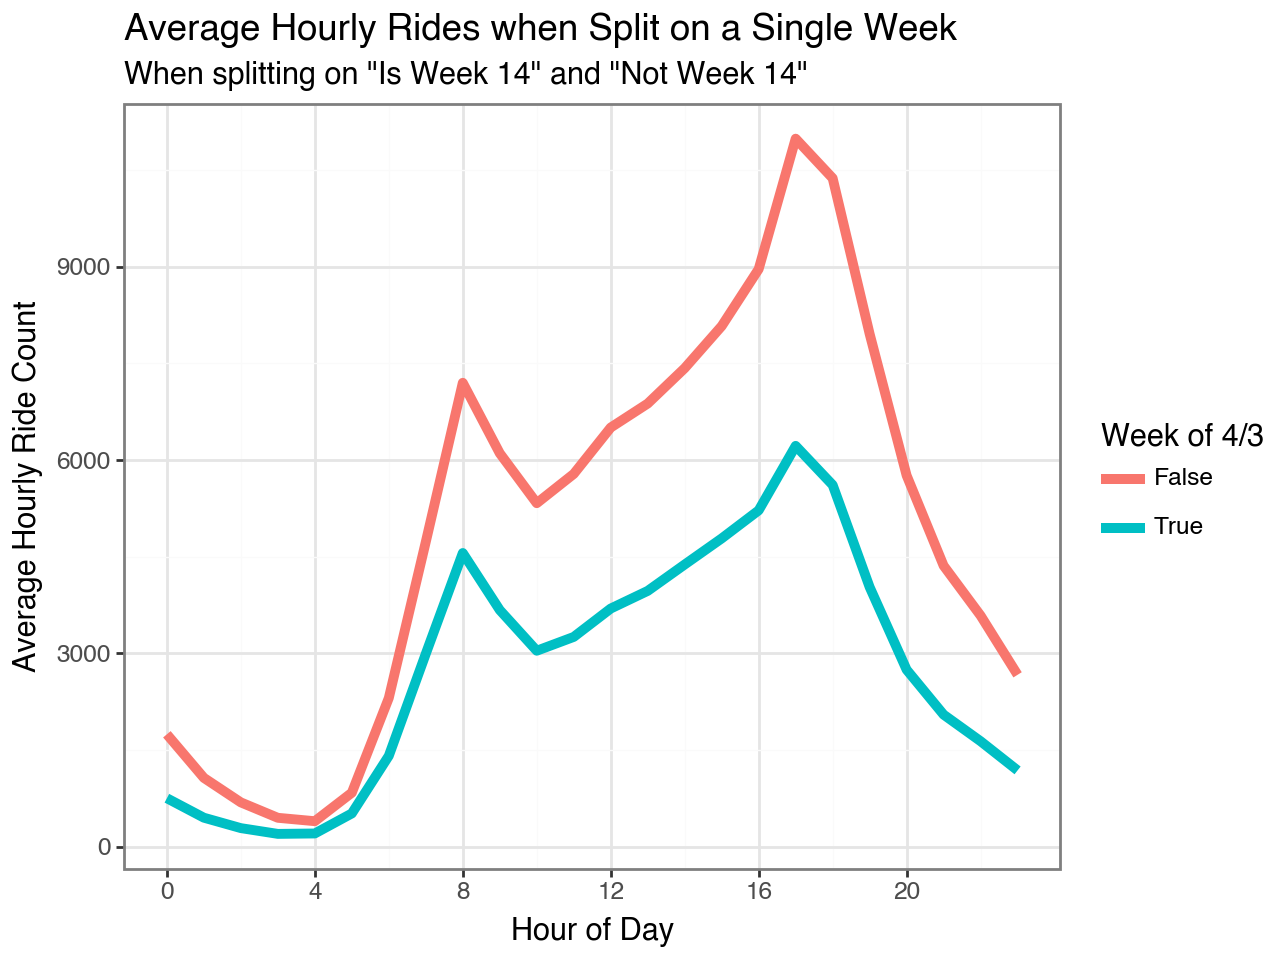

In [14]:
plot_df = (
    hourly_df.
    with_columns(is_14 = pl.col('woy') <= 14).
    group_by('is_14', 'ride_hour').agg(pl.col('ride_count').mean())
)

pn.ggplot(plot_df, pn.aes(x='ride_hour', y='ride_count', color='is_14')) +\
    pn.geom_line(size=2) +\
    pn.ylab('Average Hourly Ride Count') +\
    pn.xlab('Hour of Day') +\
    pn.scale_color_discrete(name = 'Week of 4/3') +\
    pn.scale_x_continuous(breaks=range(0, 24, 4)) +\
    pn.theme_bw() +\
    pn.ggtitle('Average Hourly Rides when Split on a Single Week') +\
    pn.labs(subtitle='When splitting on "Is Week 14" and "Not Week 14"')

I think this may be a data problem with some values missing or something. I don't know why early April would have the least amount of rides? Maybe spring break for the kids? Oh wow, [that is the answer](https://www.schools.nyc.gov/calendar/2025-2026-school-year-calendar) haha. 

### Smoothing Splines

Now we can actually get to fitting our Gradient Boosting Spline Model. If you want an introduction to splines I've written a couple different posts on this topic:

1. [How to Fit Monotonic Smooths in JAX using Shape Constrained P-Splines](https://statmills.com/2025-05-03-monotonic_spline_jax/)
2. [A first Look at some Atlanta Housing Data](https://statmills.com/2025-02-04-fha_data/)
3. [Fitting Multiple Spline Terms in Python using GLUM](https://statmills.com/2023-12-08-fitting_multiple_splines/)


For our model we have to do a little pre-processing to be ready for the fitting process

1. Build our spline basis for the 24 hour period of day
2. Write a function to generate predictions with our flattened hourly data
3. Write a function to calculate the gradient of our loss function

In [15]:
#| echo: true
N_KNOTS = 12
x_day = hourly_df['ride_hour'].unique().to_numpy().reshape(-1, 1)
spline_hour = SplineTransformer(n_knots=N_KNOTS, include_bias=True).fit(X=x_day)
N_SPLINES = spline_hour.n_features_out_

bs_day = spline_hour.transform(x_day)
print('Example of Basis Activations for different hours')
for i in range(6):
    print(f'Hour {i*4}: {display_vec(bs_day[i*4, :])}')

Example of Basis Activations for different hours
Hour 0: ▂█▂▁▁▁▁▁▁▁▁▁▁▁
Hour 4: ▁▁▃█▂▁▁▁▁▁▁▁▁▁
Hour 8: ▁▁▁▁▃█▂▁▁▁▁▁▁▁
Hour 12: ▁▁▁▁▁▁▄█▁▁▁▁▁▁
Hour 16: ▁▁▁▁▁▁▁▁▅█▁▁▁▁
Hour 20: ▁▁▁▁▁▁▁▁▁▁▆█▁▁


In [16]:
y = hourly_df['ride_count'].to_numpy()
y_log = np.log1p(y)

def init_coefs(n_splines, y):
    """Initialize with a flat prediction"""
    y_mean = y.mean()
    coefs = np.repeat(y_mean, n_splines)
    return coefs

def pred_hourly_spline(coefs, x, spline_transformer=spline_hour):
    bs = spline_transformer.transform(x)
    return np.dot(bs, coefs.T)


coefs_init = init_coefs(N_SPLINES, y_log)
preds_init = pred_hourly_spline(coefs_init, x_day, spline_hour)

Here is where things start to diverge from traditional models though. I do not want each tree $f_m(x)$ to produce a prediction of $\hat{y}_m$. I want each tree to predict the optimal spline coefficients for that gradient step $\hat{\theta}_t$. So we will need to know the gradient of the loss function for each spline coefficient and each observation. Luckily, `jax` makes this easy. We can define our loss function once that operates on a single observation. Jax will then calculate the partial deritaves automatically with `grad`. And we can scale this to an array with the `vmap` function.

In [17]:
#| eval: false
def predict_array(x_array, coefs, spline_hour=spline_hour):
    """
    x_array: [n, 24] array from polars arr.to_numpy()
    coefs: [b,] 1d array from numerical procedure
    """
    x_array_ = x_array.reshape(-1, 1)
    bs_array = spline_hour.transform(x_array_)
    pred_array = jnp.dot(bs_array, coefs.reshape(-1, 1))
    # put it back to "flat"
    return pred_array.reshape(-1, 24)

In [18]:

daily_df = daily_df.with_columns(
    y_log = pl.col('ride_count').arr.eval(pl.element().log1p())
)
X = daily_df['ride_hour'].to_numpy()
y_log = daily_df['y_log'].to_numpy()

def predict_i(coefs, bs_array):
    """
    x_array: [n, 24] array from polars arr.to_numpy()
    coefs: [b,] 1d array from numerical procedure
    """
    pred_array = jnp.dot(bs_array, coefs.reshape(-1, 1))
    # put it back to "flat"
    return pred_array.reshape(-1, 24)

predict_array = vmap(predict_i)

#predict_array(X[:3], coefs_init).round(0)[:, :5]

In [19]:
#| echo: false
# convert basis transformation to a numpy array now so Jax can use it. 
BS = spline_hour.transform(X.reshape(-1, 1))
BS_daily = BS.reshape(-1, 24, N_SPLINES)
print(BS.shape)
print(BS_daily.shape)

(34368, 14)
(1432, 24, 14)


In [37]:
#| echo: true
def loss_i(coefs, bs_array, y_array):
    """
    Calculate the scalar loss for the input, spline transformed data
    
    Parameters:
    coefs: [b,] 1d array from numerical procedure
    bs_array: [24, b] spline transformed data
    y_array: [24, 1] target values
    """
    #x_array_ = x_array.reshape(-1, 1)
    y_array_ = y_array.reshape(-1, 1)

    preds = jnp.dot(bs_array, coefs.reshape(-1, 1))
    error = jnp.power(preds - y_array_, 2)
    penalty = jnp.sum(jnp.square(jnp.diff(coefs, 1)))
    # using mean instead of sum to keep the total loss numbers low...I think that's ok
    error_array = jnp.mean(error) 
    return error_array + 0.01 * penalty

# vectorize our loss function to work on arrays
loss_array = vmap(loss_i)
# Calculate the gradient of a single observation
# grad only works on scalar output, so we have to vectorize them seperately 
grad_i = grad(loss_i)
grad_array = vmap(grad_i)

v, g = value_and_grad(loss_i)(coefs_init, BS_daily[0], y_log[0])
print(f'Loss function value for one day: {v:.2f}')
print('Gradients for each spline coefficient for that day:')
print(np.round(g, 2))

Loss function value for one day: 2.27
Gradients for each spline coefficient for that day:
[ 0.04        0.29        0.51        0.45999998  0.22        0.09999999
  0.07        0.03        0.         -0.01        0.05        0.14
  0.13        0.02      ]


In [38]:
#| eval: false
vmap(loss_i, in_axes=(None, 0, 0))(coefs_init, BS_daily[:5], y_log[:5])

Array([2.2650287, 1.5534806, 1.7464765, 1.3803082, 1.4017327], dtype=float32)

In [39]:
#| eval: false
grad_i(coefs_init, BS_daily[0], y_log[0])

Array([ 3.5758778e-02,  2.8992504e-01,  5.1199454e-01,  4.6131155e-01,
        2.2437428e-01,  1.0000248e-01,  7.1121059e-02,  3.3098020e-02,
        2.9693797e-04, -9.2351278e-03,  5.0804634e-02,  1.3755490e-01,
        1.2875412e-01,  2.0316992e-02], dtype=float32)

In [40]:
#| eval: false
vmap(grad_i, in_axes=(None, 0, 0))(coefs_init, BS_daily[:5], y_log[:5]).round(2)

Array([[ 0.04      ,  0.29      ,  0.51      ,  0.45999998,  0.22      ,
         0.09999999,  0.07      ,  0.03      ,  0.        , -0.01      ,
         0.05      ,  0.14      ,  0.13      ,  0.02      ],
       [ 0.02      ,  0.21      ,  0.42      ,  0.35999998,  0.06      ,
        -0.08      , -0.05      , -0.07      , -0.09999999, -0.12      ,
        -0.08      ,  0.06      ,  0.09999999,  0.02      ],
       [ 0.01      ,  0.14      ,  0.32      ,  0.22999999, -0.08      ,
        -0.22      , -0.17999999, -0.17      , -0.22      , -0.28      ,
        -0.25      , -0.14      , -0.04      , -0.        ],
       [ 0.02      ,  0.19      ,  0.35999998,  0.28      , -0.01      ,
        -0.14      , -0.08      , -0.08      , -0.14      , -0.19999999,
        -0.17      , -0.04      ,  0.04      ,  0.01      ],
       [-0.        , -0.01      ,  0.09      ,  0.19      ,  0.08      ,
        -0.11      , -0.22999999, -0.28      , -0.29      , -0.28      ,
        -0.22      , -0.14

I've initialized some coefficients to predict a flat line, `coefs_init`. We can calculate our initial gradients and thus psuedo-labels to use in the first tree with our gradient functions. One technical note is the coefficient vector needs to be the same length as the X and Y arrays I'm using for vmap to accept it. Once we start fitting trees this will be the case, but when I created by coefs_init values originally I just used a 1d array for all values. That's why in the following code cell I repeat it to match the length of our data. 

In [41]:
#| echo: true
coefs_init_array = np.tile(coefs_init, (daily_df.shape[0], 1))
labels_init = -grad_array(coefs_init_array, BS_daily, y_log)
print(labels_init.shape)

(1432, 14)


### Gradient Boosting Splines

We now have everything we need to update our spline coefficients:

1. `coefs_init`: an initial set of smoothing splines to produce a flat prediction
2. `grad_array`: a function to calculate the gradients of our predictions with respect to the coefficients at each observation
3. `labels_init`: The initial gradient values to use as a our psuedo-labels for our first iteration

Lets fit one decision tree with our features to predict the gradients of the splines for each observation

In [42]:
#| echo: true
from sklearn.tree import DecisionTreeRegressor

x_features = daily_df[FEATURE_COLS].to_numpy()

tree_init = DecisionTreeRegressor(max_depth=2).fit(x_features, labels_init)

In [43]:

def print_tree(node, depth=0):
    indent = "  " * depth
    if depth > 3:
        return
    if tree_init.tree_.feature[node] >= 0:
        feature = FEATURE_COLS[tree_init.tree_.feature[node]]
        threshold = round(tree_init.tree_.threshold[node], 1)
        print(f"{indent}{feature} <= {threshold}")
        print_tree(tree_init.tree_.children_left[node], depth + 1)
        if depth < 2:
            print(f"{indent}else:")
        print_tree(tree_init.tree_.children_right[node], depth + 1)
    else:
        pass

print("Tree splits:")
print_tree(0)


Tree splits:
low_temp <= 57.5
  dow <= 5.5
  else:
else:
  dow <= 5.5
  else:


In [44]:
daily_gbm_imp = {
    col: imp
    for col, imp in zip(FEATURE_COLS, tree_init.feature_importances_)}
# order dictionary by importance
daily_gbm_imp = dict(sorted(daily_gbm_imp.items(), key=lambda item: item[1], reverse=True))
print('First Tree Feature Importances:')
for col, imp in daily_gbm_imp.items():
    print(f'{col}: {imp * 100:.2f}%')


First Tree Feature Importances:
low_temp: 64.93%
dow: 35.07%
woy: 0.00%
year: 0.00%
high_temp: 0.00%
precip: 0.00%


We can see how the different predictions look for this leaf nodes of this simple tree:

In [45]:
#| output: false
init_coef_preds = tree_init.predict(x_features)
print(init_coef_preds.shape)
coefs_0 = coefs_init_array + init_coef_preds
init_preds = predict_array(coefs_0, BS_daily)
print(init_preds.shape)

(1432, 14)
(1432, 1, 24)


In [46]:
init_preds_2d = np.asarray(init_preds).squeeze(1)
daily_df = daily_df.with_columns(pl.Series("init_preds", init_preds_2d.tolist()).list.to_array(24))
daily_df = daily_df.with_columns(
    init_label = pl.when(pl.col('low_temp') < 57.5).
        then(pl.when(pl.col('dow') < 5.5).then(pl.lit('Cold Weekday')).otherwise(pl.lit('Cold Weekend'))).
        otherwise(pl.when(pl.col('dow') < 5.5).then(pl.lit('Warm Weekday')).otherwise(pl.lit('Warm Weekend')))
)


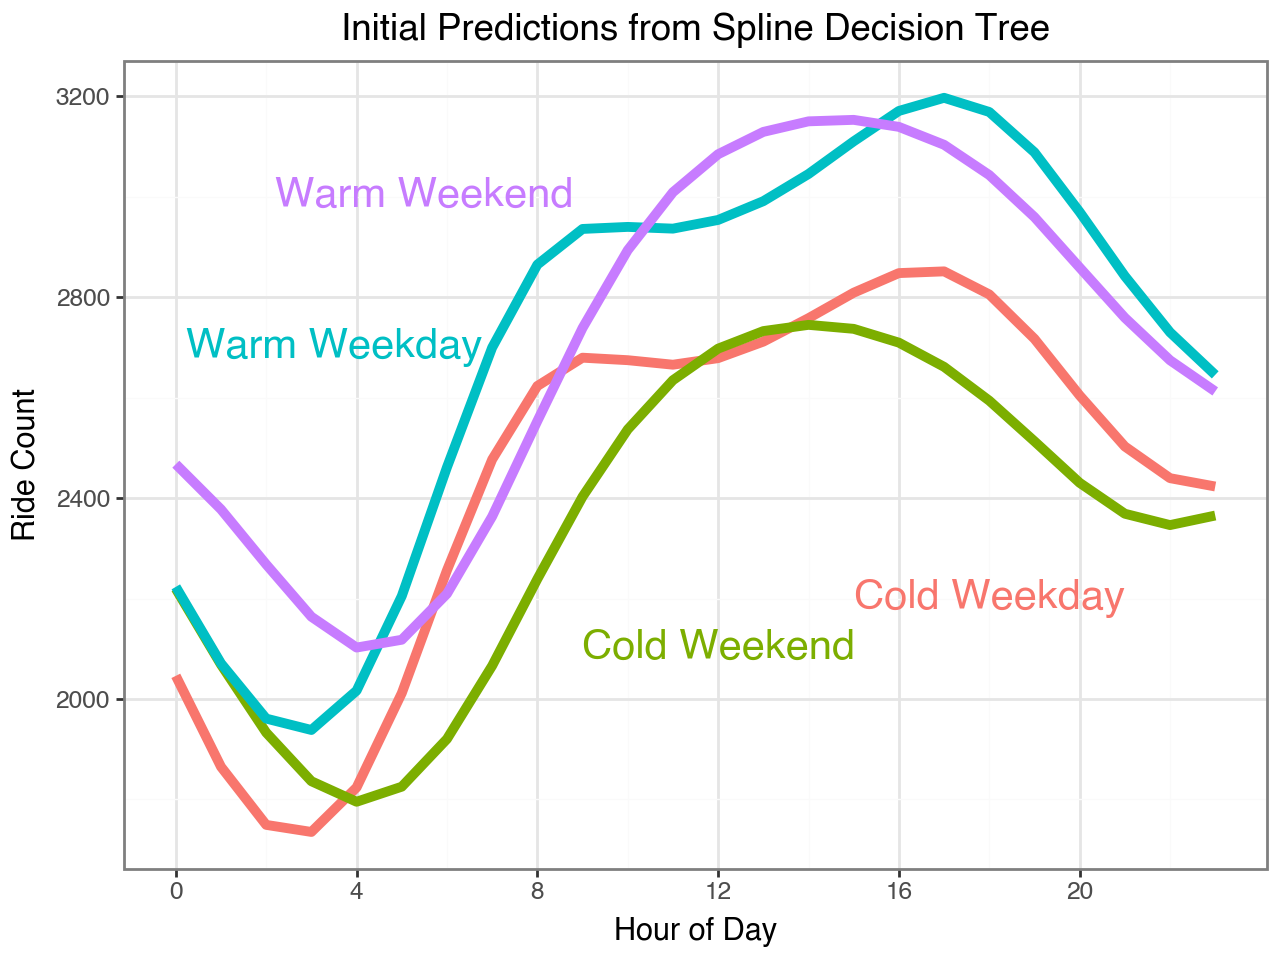

In [47]:
plot_df =(
    daily_df.
    group_by('init_label').head(1).
    explode("ride_hour", "init_preds", "ride_count").
    with_columns(y = pl.col('init_preds').exp() - 1)
)

levels = ["Warm Weekday", "Warm Weekend", "Cold Weekend", "Cold Weekday"]
colors = pn.scale_color_hue().palette(len(levels))
size_ = 15

pn.ggplot(plot_df, pn.aes(x='ride_hour', y='y', color='init_label')) +\
    pn.geom_line(size=2) +\
    pn.xlab('Hour of Day') +\
    pn.ylab('Ride Count') +\
    pn.scale_x_continuous(breaks=range(0, 24, 4)) +\
    pn.theme_bw() +\
    pn.ggtitle(title='Initial Predictions from Spline Decision Tree') +\
    pn.scale_color_discrete(guide=None) +\
    pn.annotate(geom='text', x=3.5, y=2700, label='Warm Weekday', color=colors[2], size=size_) +\
    pn.annotate(geom='text', x=5.5, y=3000, label='Warm Weekend', color=colors[3], size=size_) +\
    pn.annotate(geom='text', x=12, y=2100, label='Cold Weekend', color=colors[1], size=size_) +\
    pn.annotate(geom='text', x=18, y=2200, label='Cold Weekday', color=colors[0], size=size_)
            
    
#pn.geom_point(pn.aes(y='ride_count')) +\

What I love is we can immediately see the different shapes in the weeks and weekdays. Our classic GBM had to learn the trend at each hour of the day so it took a while until the differences in curves was the largest residual signal left to optimize against. But with our Gradient Boosted Splines oue model can learn the full curve in one go. 

I also want to point out I'm not clustering the data and then fitting a model to each subset of data to learn the coefficients. These predictions are only coming from predicting the gradients of the loss function on each day from a flat line. The model learns the optimal splits to cluster the data with for optimizing our loss function. We've basically created a supervised clustering algorithm. 

In [48]:
#| output: false
levels = ["Warm Weekday", "Warm Weekend", "Cold Weekend", "Cold Weekday"]
colors = dict(zip(levels, pn.scale_color_hue().palette(len(levels))))
size_ = 10

label_positions = {
    "Warm Weekday": (3.5, 2900),
    "Warm Weekend": (5.5, 3000),
    "Cold Weekend": (12, 2100),
    "Cold Weekday": (18, 2200),
}

for label in levels:
    x_label, y_label = label_positions[label]

    p = (
        pn.ggplot()
        + pn.geom_line(
            data=plot_df.filter(pl.col("init_label") != label),
            mapping=pn.aes(x="ride_hour", y="y", group="init_label"),
            color="darkgrey",
            size=2,
        )
        + pn.geom_line(
            data=plot_df.filter(pl.col("init_label") == label),
            mapping=pn.aes(x="ride_hour", y="y"),
            color=colors[label],
            size=2,
        )
        + pn.annotate(
            geom="text",
            x=x_label,
            y=y_label,
            label=label,
            color=colors[label],
            size=size_,
        )
        + pn.xlab("Hour of Day")
        + pn.ylab("Ride Count")
        + pn.scale_x_continuous(breaks=range(0, 24, 4))
        + pn.theme_bw()
        + pn.theme(
            axis_text_x=pn.element_blank(),
            axis_text_y=pn.element_blank(),
            plot_title=pn.element_blank(),
        )
    )

    p.save(
        f"init_preds_{label.lower().replace(' ', '_')}.png",
        width=3,
        height=3,
        dpi=300,
    )


/Users/mm/Documents/Data Science/Blog Posts/grf/.venv310/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 3 x 3 in image.
/Users/mm/Documents/Data Science/Blog Posts/grf/.venv310/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: init_preds_warm_weekday.png
/Users/mm/Documents/Data Science/Blog Posts/grf/.venv310/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 3 x 3 in image.
/Users/mm/Documents/Data Science/Blog Posts/grf/.venv310/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: init_preds_warm_weekend.png
/Users/mm/Documents/Data Science/Blog Posts/grf/.venv310/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 3 x 3 in image.
/Users/mm/Documents/Data Science/Blog Posts/grf/.venv310/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: init_preds_cold_weekend.png
/Users/mm/Documents/Data Science/Blog Posts/grf/.venv31

### Gradient Boosted Splines

We now have everything we need to fit our Gradient Boosting models to try and improve our predictions. 

In [49]:
#| echo: true
def fit_tree_and_update(
        coefs,
        bs_array=BS_daily,
        y_array=y_log,
        x_features=x_features,
        lr=0.1):
    """Fit a single tree and update the predictions"""
    # 1. Calculate Gradients
    labels = grad_array(coefs, bs_array, y_array)
    # 2. Fit a tree
    tree = DecisionTreeRegressor(max_depth=2).fit(x_features, labels)
    # 3. Get predictions of the spline coefficients
    tree_preds = tree.predict(x_features)
    # 4. Update our model fits
    new_coefs = coefs - lr * tree_preds
    return new_coefs, tree, tree_preds

N_TREES = 500

preds_init = predict_array(coefs_init_array, BS_daily).squeeze(1)
loss_init = loss_array(coefs_init_array, BS_daily, y_log).mean()

tree_params = coefs_init_array
spline_trees = []
for i in range(N_TREES):
    result = fit_tree_and_update(tree_params, BS_daily, y_log, x_features)
    tree_params = result[0]
    spline_trees.append(result)

# get the last tree's predictions
coef_fit = spline_trees[-1][0]
preds_fit = predict_array(coef_fit, BS_daily).squeeze(1)
loss_fit = loss_array(coef_fit, BS_daily, y_log).mean()

print(f'Initial loss: {loss_init}')
print(f'Final loss: {loss_fit}')

Initial loss: 1.5850720405578613
Final loss: 0.2547141909599304


So the model (`spline_trees`) predicts a **coefficient vector** for each observation. To get predictions for each hour at each observation (an observation is a single day's hourly totals) we need to apply each coefficient vector against the Spline Basis we created for the 24 hour period initially. `predict_array` is a function I wrote to generate the *actual* hourly predictions based off a customized coefficient vector. 

In [50]:
print(preds_fit[0].round(2))
print(y_log[0].round(2))

[5.89      5.3199997 4.91      4.83      5.12      5.75      6.5099998
 7.1       7.44      7.5499997 7.5499997 7.5699997 7.6499996 7.77
 7.89      7.99      8.04      8.        7.85      7.6099997 7.3199997
 7.0699997 6.92      6.92     ]
[5.66 5.13 4.75 4.62 4.5  5.84 6.61 7.04 7.4  7.37 7.33 7.46 7.6  7.74
 7.79 7.87 7.98 7.97 7.85 7.51 7.2  6.99 6.87 6.52]


In [51]:
preds_fit_2d = np.asarray(preds_fit)  # (1432, 24)

test_df = daily_df.with_columns(
    pl.Series("preds_fit", preds_fit_2d.tolist())
).with_columns(
    pl.col("preds_fit").list.to_array(24)
)


In [52]:
#| output: false
def array_to_tall_df(daily_df):
    """Convert the wide array of predictions back to a tall format for plotting"""
    return (
        daily_df.
        explode('ride_hour', 'preds_fit', 'y_log'))
    
plot_splines_df = array_to_tall_df(test_df.filter(pl.col('year') == 2025, pl.col('woy').is_in([1, 10, 20, 30, 40]), pl.col('dow').is_in([1, 6])))
plot_splines_df.head()

dow,woy,year,high_temp,low_temp,precip,ride_date,ride_hour,ride_count,y_log,init_preds,init_label,preds_fit
i8,i8,i32,f64,f64,f64,date,i64,"array[u32, 24]",f64,"array[f64, 24]",str,f64
6,20,2025,62.06,84.92,0.0,2025-05-17,0,"[4399, 2986, … 5872]",8.38936,"[7.811409, 7.774265, … 7.868422]","""Warm Weekend""",7.812662
6,20,2025,62.06,84.92,0.0,2025-05-17,1,"[4399, 2986, … 5872]",8.002025,"[7.811409, 7.774265, … 7.868422]","""Warm Weekend""",7.642476
6,20,2025,62.06,84.92,0.0,2025-05-17,2,"[4399, 2986, … 5872]",7.571988,"[7.811409, 7.774265, … 7.868422]","""Warm Weekend""",7.338872
6,20,2025,62.06,84.92,0.0,2025-05-17,3,"[4399, 2986, … 5872]",7.064759,"[7.811409, 7.774265, … 7.868422]","""Warm Weekend""",6.997283
6,20,2025,62.06,84.92,0.0,2025-05-17,4,"[4399, 2986, … 5872]",6.669498,"[7.811409, 7.774265, … 7.868422]","""Warm Weekend""",6.788791


Lets compare our fitted Gradient Boosted Spline to our initial GBM. The model is still undershooting the peaks and misses something about the January 1st day (I should probably add a `Is_Holiday` feature). But we get smooth curves! From Gradient Boosting! Its amazing that this approach can be so easily accomplished with code by leveraging open source tools like Jax and Scikit-Learn. All you need is a loss function and a way to express individual predictions from a set of parameters and you can fit any model this way. 

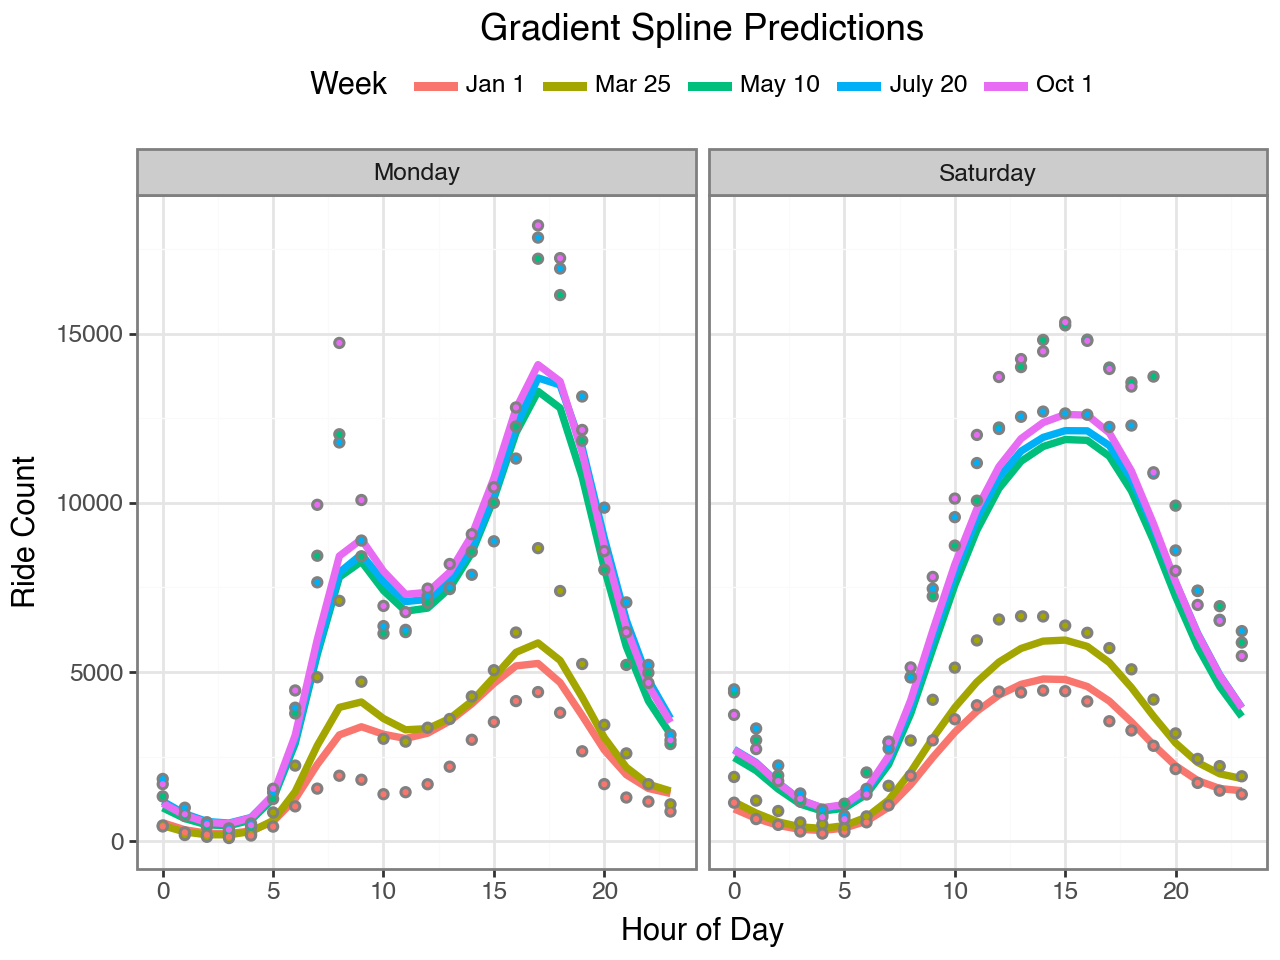

In [53]:
woy_levels = ["Jan 1", "Mar 25", "May 10", "July 20", "Oct 1"]


plot_splines_df = (
    plot_splines_df.
    with_columns(dow_ = pl.when(pl.col('dow') < 5).then(pl.lit('Monday')).otherwise(pl.lit('Saturday')),
                 woy_ = pl.when(pl.col('woy') == 1).then(pl.lit('Jan 1')).
                        when(pl.col('woy') == 10).then(pl.lit('Mar 25')).
                        when(pl.col('woy') == 20).then(pl.lit('May 10')).
                        when(pl.col('woy') == 30).then(pl.lit('July 20')).
                        when(pl.col('woy') == 40).then(pl.lit('Oct 1')).
                        otherwise(pl.lit('Other')).cast(pl.Enum(woy_levels)),
                pred = pl.col('preds_fit').exp() - 1,
                y = pl.col('y_log').exp() - 1)

)

(
    pn.ggplot(plot_splines_df.to_pandas(), pn.aes(x='ride_hour', y='pred', color='woy_', group = 'woy')) +
    pn.geom_line(size=1.5) +
    pn.facet_wrap('dow_') +
    pn.geom_point(pn.aes(x='ride_hour', y='y'), color='grey') +
    pn.geom_point(pn.aes(x='ride_hour', y='y', color='woy_'), size=0.25) +
    pn.theme_bw() +
    pn.theme(legend_position='top') +\
    pn.scale_color_discrete(name='Week') +
    pn.ggtitle('Gradient Spline Predictions') +\
    pn.xlab('Hour of Day') +
    pn.ylab('Ride Count') 
)

I'm sure there are tons of valid inference questions you could ask of this approach; I don't have those answers. But I think that will be it for today's post. I'm excited to take this concept even further to fit more types of models. If you want to make sure you see any future post I write you can follow me @statmills on [Twitter](https://x.com/statmills) or [BlueSky](https://bsky.app/profile/statmills.bsky.social). If you are interested in the code for this blog post I've added everything to my [github repo](https://github.com/mattmills49/Blog-Posts). 

*Humanity Oath: I solemnly swear that I did not use AI to write the words in this piece.*

